In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

In [2]:
#importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans,DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import pickle

In [ ]:
#reading the dataset
df=pd.read_excel("dataset.xlsx")
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [4]:
df.shape

(2704, 25)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Number of Records'].value_counts()

Number of Records
1    2704
Name: count, dtype: int64

In [7]:
df[['GDP','Tourism Inbound','Tourism Outbound','Health Exp/Capita','Business Tax Rate']].head()

,GDP,Tourism Inbound,Tourism Outbound,Health Exp/Capita,Business Tax Rate
0,"$54,790,058,957","$102,000,000","$193,000,000",$60,NaN
1,"$9,129,594,819","$34,000,000","$146,000,000",$22,NaN
2,"$2,359,122,303","$77,000,000","$50,000,000",$15,NaN
3,"$5,788,311,645","$227,000,000","$209,000,000",$152,NaN
4,"$2,610,959,139","$23,000,000","$30,000,000",$12,NaN


In [8]:
# Removing $, commas, % from relevant columns and converting them to numeric
df['GDP'] = df['GDP'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Inbound'] = df['Tourism Inbound'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Outbound'] = df['Tourism Outbound'].replace(r'[\$,]', '', regex=True).astype(float)
df['Health Exp/Capita'] = df['Health Exp/Capita'].replace(r'[\$,]', '', regex=True).astype(float)
df['Business Tax Rate'] = df['Business Tax Rate'].replace('%', '', regex=True).astype(float)

In [9]:
df[['GDP','Tourism Inbound','Tourism Outbound','Health Exp/Capita','Business Tax Rate']].head()

,GDP,Tourism Inbound,Tourism Outbound,Health Exp/Capita,Business Tax Rate
0,5.479006e+10,102000000.0,193000000.0,60.0,NaN
1,9.129595e+09,34000000.0,146000000.0,22.0,NaN
2,2.359122e+09,77000000.0,50000000.0,15.0,NaN
3,5.788312e+09,227000000.0,209000000.0,152.0,NaN
4,2.610959e+09,23000000.0,30000000.0,12.0,NaN


In [10]:
#finding missing value percentage of each columns
null_cols=df.isnull().sum()/len(df)*100
null_cols.sort_values(ascending=False)

Ease of Business          93.158284
Hours to do Tax           47.633136
Business Tax Rate         47.374260
Days to Start Business    36.464497
Energy Usage              33.986686
Lending Interest          30.473373
CO2 Emissions             21.412722
Tourism Outbound          17.418639
Tourism Inbound           13.609467
Health Exp/Capita         11.427515
Health Exp % GDP          11.427515
Infant Mortality Rate      9.615385
Population 15-64           8.136095
Population 65+             8.136095
Population 0-14            8.136095
GDP                        7.766272
Internet Usage             6.397929
Mobile Phone Usage         6.176036
Life Expectancy Female     5.029586
Life Expectancy Male       5.029586
Birth Rate                 4.400888
Population Urban           0.961538
Country                    0.000000
Number of Records          0.000000
Population Total           0.000000
dtype: float64

In [11]:
null_cols['GDP']

np.float64(7.766272189349112)

In [12]:
#dropping columns having missing value percentage greater than 40%
df.drop(columns=['Ease of Business','Hours to do Tax','Business Tax Rate',"Number of Records"],inplace=True)

In [13]:
df.shape

(2704, 21)

In [14]:
#finding all the numerical columns 
num_cols=[i for i in df.select_dtypes(['int','float']).columns]

In [15]:
#dropping rows in numerical column having missing value percentage less than 5%
#replacing missing values in columns having missing value percenntage greater than 5%
for i in num_cols:
    if (null_cols[i]<5):
        df.dropna(subset=[i], inplace=True)
        df.reset_index(drop=True, inplace=True)
    else:
        df.fillna({i:df[i].median()},inplace=True)

In [16]:
df.isnull().sum()

Birth Rate                0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64

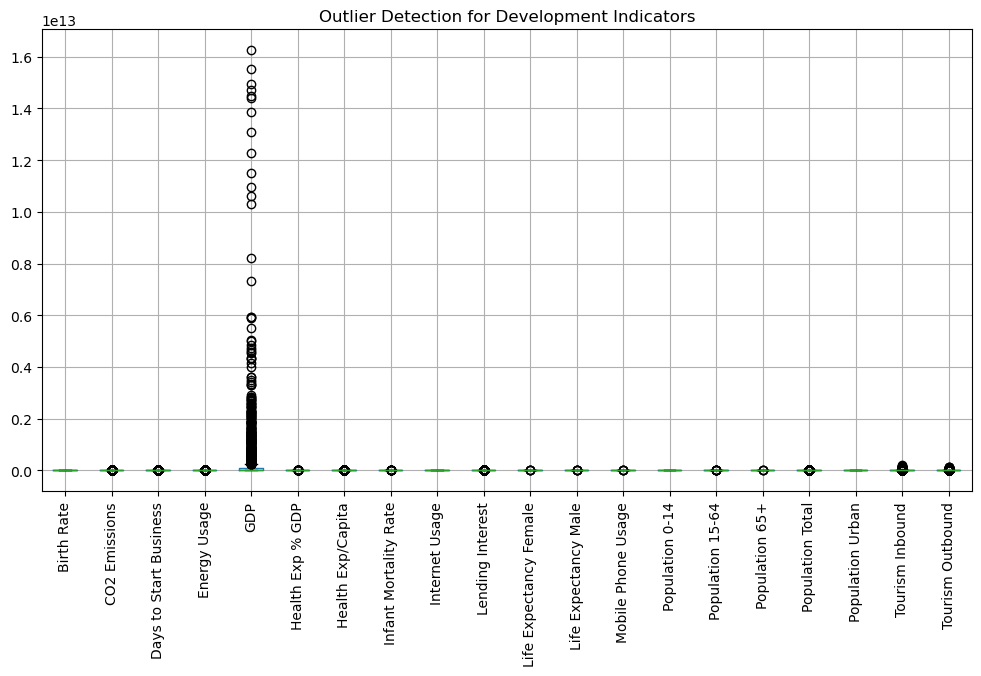

In [17]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.title("Outlier Detection for Development Indicators")
plt.xticks(rotation=90)
plt.show()

In [18]:
#outlier capping
def outlier_capping(df,column):
  q1= df[column].quantile(0.25)
  q3= df[column].quantile(0.75)
  iqr= q3-q1
  lower_extreme= q1-1.5*iqr
  upper_extreme= q3+1.5*iqr
  df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
  outlier_capping(df,col)

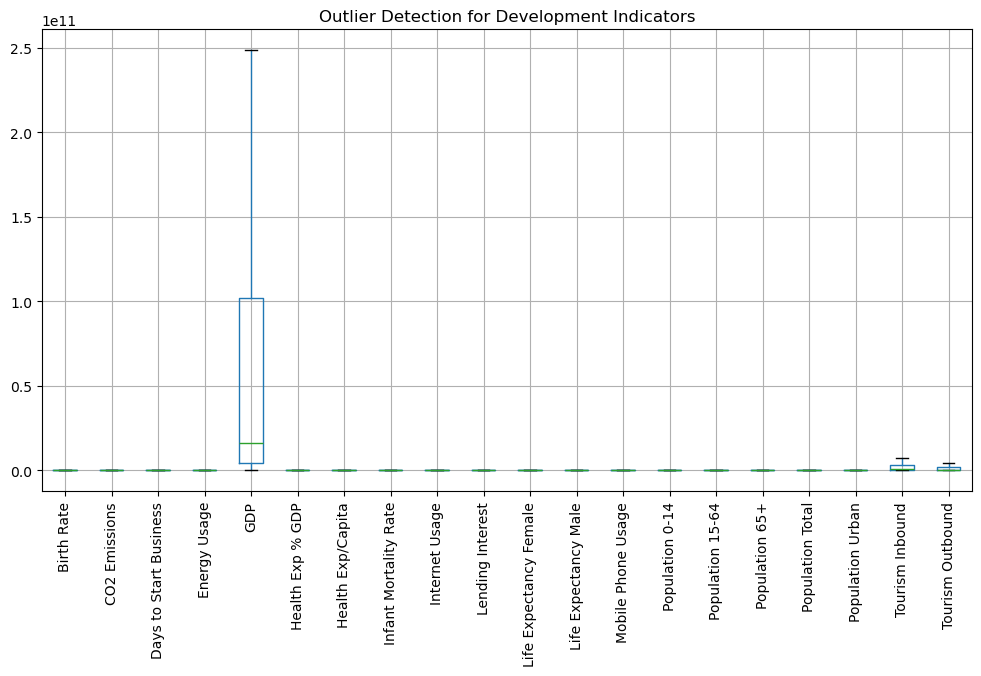

In [19]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.title("Outlier Detection for Development Indicators")
plt.xticks(rotation=90)
plt.show()

we are using groupby() function to get agregated values for each country

In [20]:
df_country=df.groupby('Country').mean()
df_country

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Country,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.043154,3478.230769,13.923077,14457.000000,1.023006e+10,0.087154,54.769231,0.082769,0.023077,0.141385,58.769231,56.384615,0.292308,0.490308,0.488769,0.020769,2.539926e+07,0.232923,4.943077e+08,3.221538e+08
Albania,0.014692,4769.769231,23.923077,2980.923077,8.895522e+09,0.061462,168.846154,0.017769,0.192308,0.142385,79.230769,73.000000,0.561538,0.258385,0.653692,0.087923,2.956845e+06,0.478538,1.165231e+09,1.007077e+09
Algeria,0.022077,86690.384615,25.461538,32535.615385,1.190391e+11,0.038462,133.846154,0.027769,0.069231,0.083231,71.615385,68.384615,0.492308,0.292692,0.663077,0.044231,3.476067e+07,0.645154,2.752308e+08,4.513077e+08
American Samoa,0.020500,9542.000000,27.000000,14457.000000,1.636344e+10,0.061000,187.500000,0.021000,0.100000,0.120000,75.000000,69.000000,0.500000,0.300000,0.642000,0.052000,5.714400e+04,0.878000,7.370000e+08,4.720000e+08
Andorra,0.010583,1288.000000,27.000000,14457.000000,5.792145e+09,0.062500,1328.666667,0.003083,0.458333,0.120000,75.000000,69.000000,0.691667,0.300000,0.642000,0.052000,7.658567e+04,0.899500,7.370000e+08,4.720000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,0.016769,78989.615385,39.346154,39865.192308,7.791354e+10,0.060769,51.692308,0.023154,0.169231,0.116308,79.538462,70.076923,0.546154,0.266154,0.668538,0.065385,5.168054e+07,0.279462,2.937000e+09,9.973846e+08
Virgin Islands (U.S.),0.013000,9542.000000,27.000000,14457.000000,1.636344e+10,0.061000,187.500000,0.021000,0.292308,0.120000,81.769231,75.538462,0.492308,0.224769,0.661000,0.114308,1.073368e+05,0.938308,1.178769e+09,4.720000e+08
"Yemen, Rep.",0.034923,17814.923077,35.192308,7128.538462,2.065261e+10,0.048308,49.000000,0.054769,0.053846,0.194135,63.076923,60.384615,0.215385,0.448077,0.524769,0.027231,2.066415e+07,0.295154,4.613077e+08,2.243077e+08


- The original dataset contains multiple records per country across different years.
- df.groupby('Country').mean() ensures each country has now one aggregated row.

In [21]:
# Applying log transformation to reduce skewness in the data
df_country = np.log1p(df_country)

In [22]:
df_country.shape

(204, 20)

In [23]:
#finding correlation
corr=df_country.corr()
corr

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Birth Rate,1.000000,-0.459876,0.358369,-0.241944,-0.431152,-0.230881,-0.752568,0.880785,-0.747823,0.460637,-0.857354,-0.824558,-0.745552,0.936809,-0.922918,-0.746607,0.162201,-0.603110,-0.568770,-0.455160
CO2 Emissions,-0.459876,1.000000,-0.187476,0.682228,0.906098,0.046497,0.409438,-0.403319,0.392060,-0.296289,0.405573,0.392076,0.413396,-0.519177,0.480728,0.445776,0.640389,0.414367,0.741998,0.828697
Days to Start Business,0.358369,-0.187476,1.000000,-0.173326,-0.230886,-0.351618,-0.395115,0.356648,-0.492667,0.350087,-0.386805,-0.406774,-0.388883,0.416268,-0.346520,-0.400825,0.005122,-0.322807,-0.316119,-0.279730
Energy Usage,-0.241944,0.682228,-0.173326,1.000000,0.619029,-0.009302,0.190449,-0.156283,0.295172,-0.259191,0.170013,0.176601,0.204767,-0.258167,0.218000,0.237191,0.446447,0.156740,0.520365,0.521667
GDP,-0.431152,0.906098,-0.230886,0.619029,1.000000,0.079129,0.443224,-0.379946,0.472069,-0.313606,0.388227,0.386785,0.462029,-0.517094,0.448377,0.475272,0.660997,0.490732,0.810727,0.881898
Health Exp % GDP,-0.230881,0.046497,-0.351618,-0.009302,0.079129,1.000000,0.400946,-0.206067,0.374981,-0.061208,0.191014,0.204742,0.216130,-0.315952,0.092348,0.526374,0.009720,0.211934,0.150225,0.163717
Health Exp/Capita,-0.752568,0.409438,-0.395115,0.190449,0.443224,0.400946,1.000000,-0.786107,0.795680,-0.517290,0.702341,0.707315,0.784459,-0.772379,0.709741,0.672921,-0.172892,0.684750,0.571942,0.501423
Infant Mortality Rate,0.880785,-0.403319,0.356648,-0.156283,-0.379946,-0.206067,-0.786107,1.000000,-0.720897,0.480147,-0.927484,-0.912053,-0.738679,0.819778,-0.814539,-0.649394,0.184431,-0.603464,-0.539932,-0.421323
Internet Usage,-0.747823,0.392060,-0.492667,0.295172,0.472069,0.374981,0.795680,-0.720897,1.000000,-0.534214,0.707928,0.724471,0.814069,-0.759478,0.665060,0.692632,-0.146016,0.615392,0.595131,0.522803
Lending Interest,0.460637,-0.296289,0.350087,-0.259191,-0.313606,-0.061208,-0.517290,0.480147,-0.534214,1.000000,-0.468897,-0.501926,-0.465711,0.476662,-0.454936,-0.384334,0.076715,-0.342646,-0.437576,-0.386477


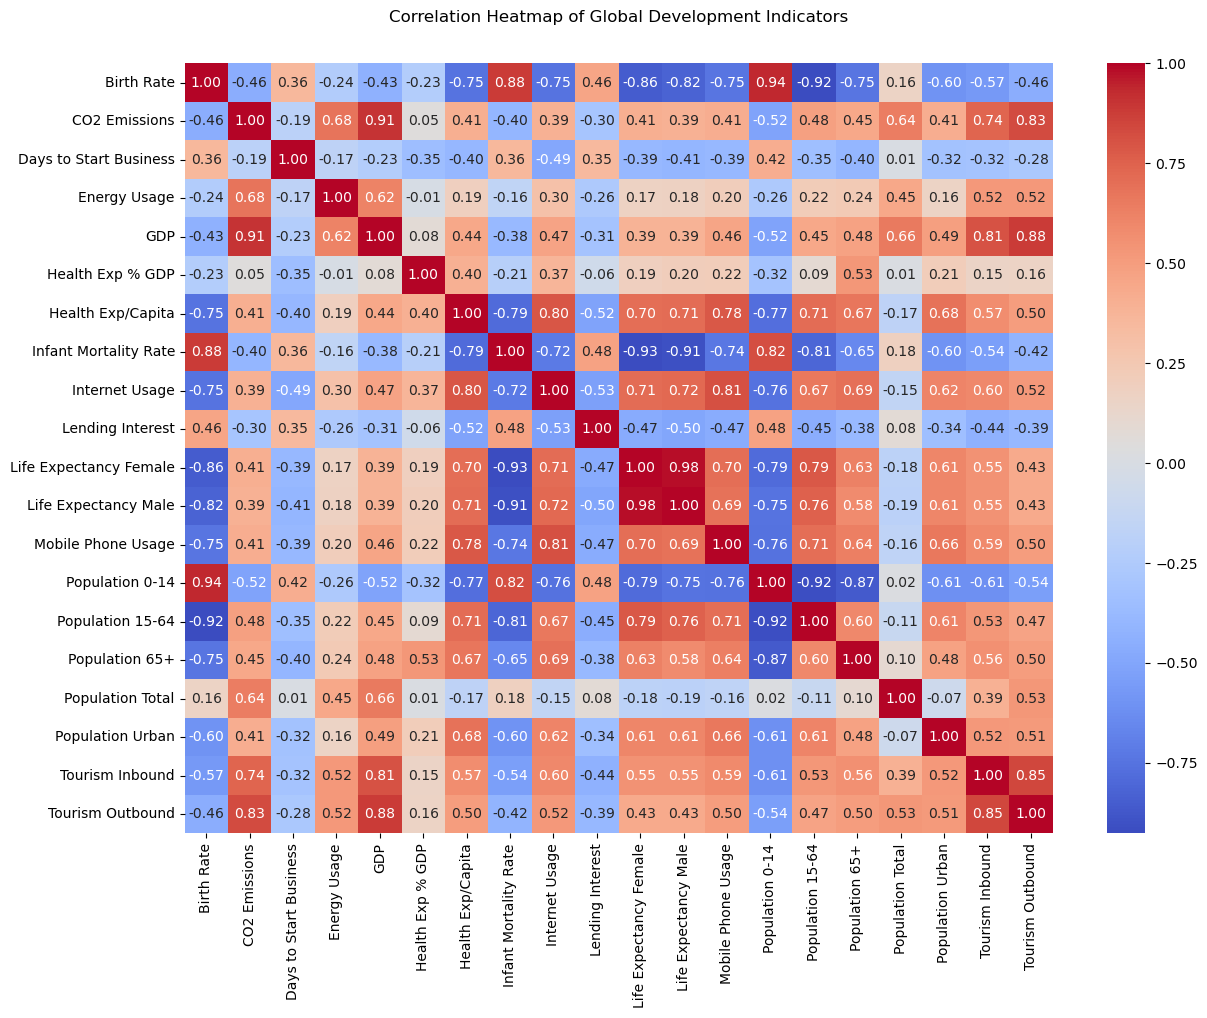

In [24]:
#used Heatmap to visualize correlation
plt.figure(figsize=(14,10))
sns.heatmap(corr,cmap="coolwarm",annot=True,fmt= ".2f")
plt.title("Correlation Heatmap of Global Development Indicators",pad=30)
plt.show()

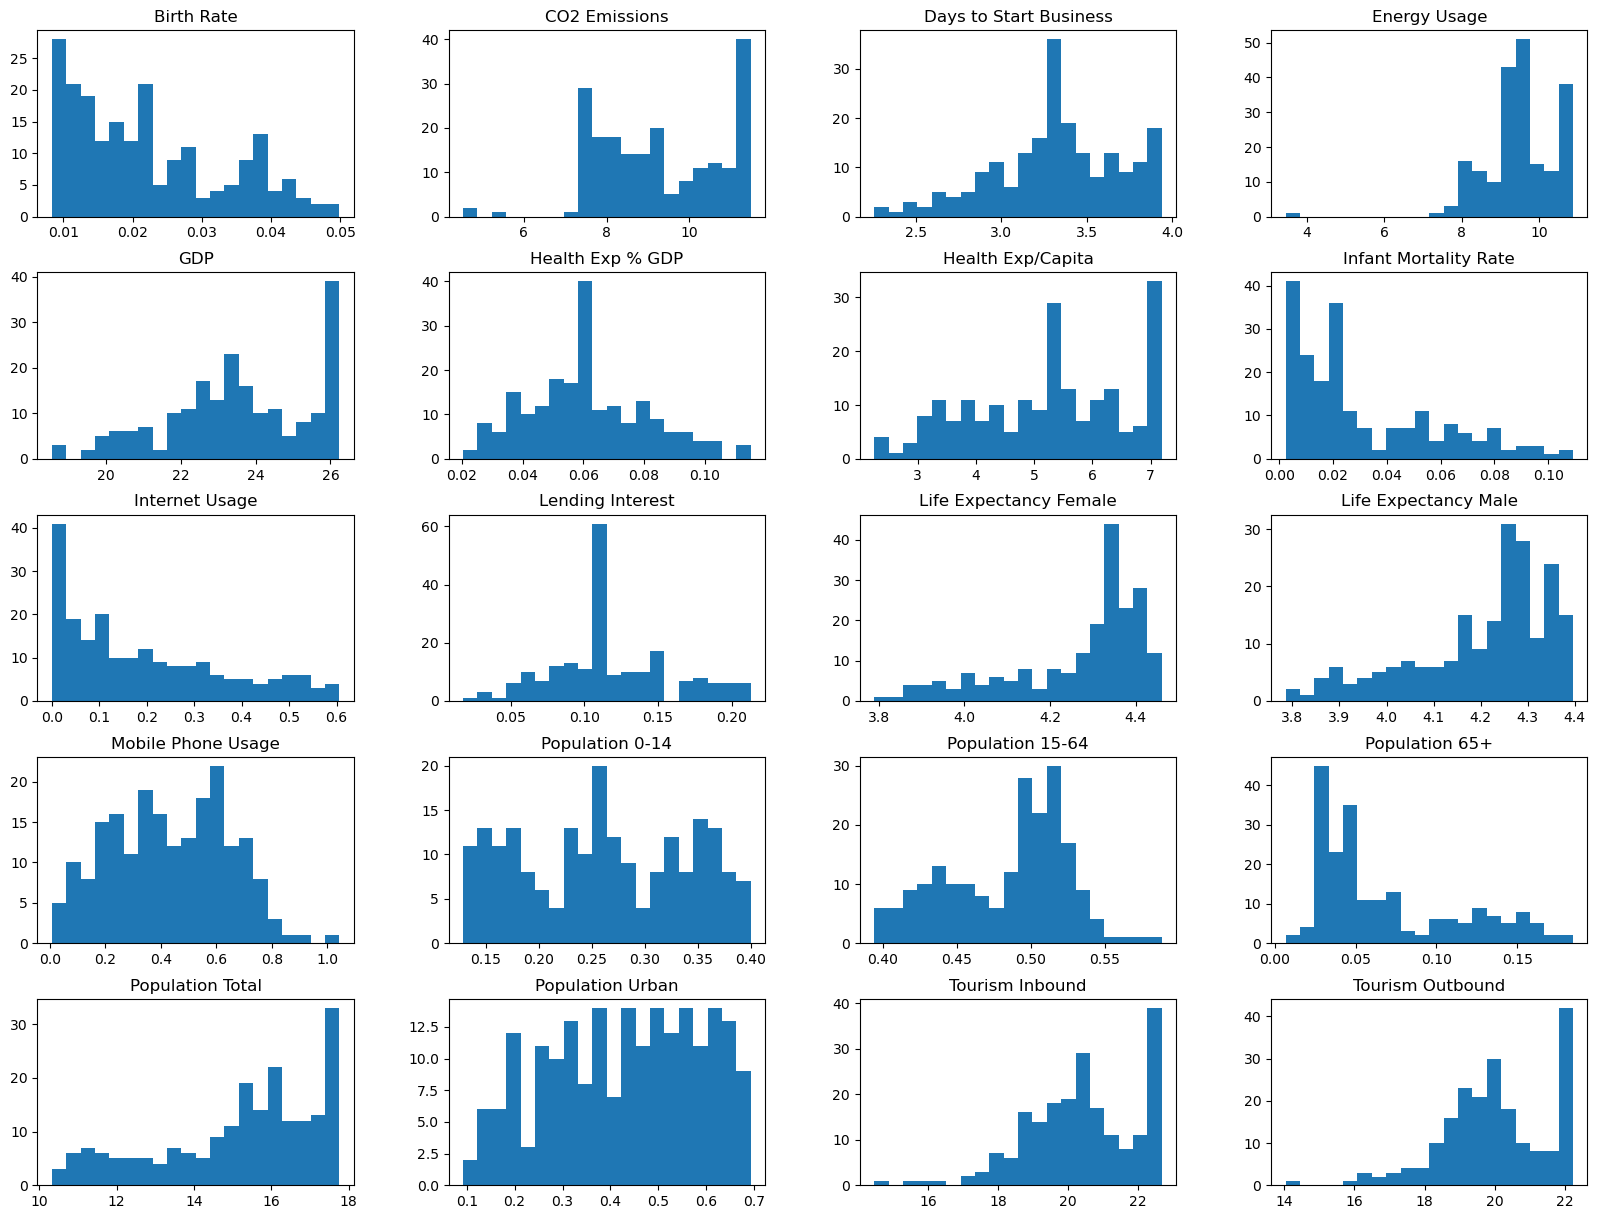

In [25]:
# Plotting histograms for all numeric variables to understand their distribution
df_country.hist(bins=20, figsize=(20,15), grid=False)
plt.show()

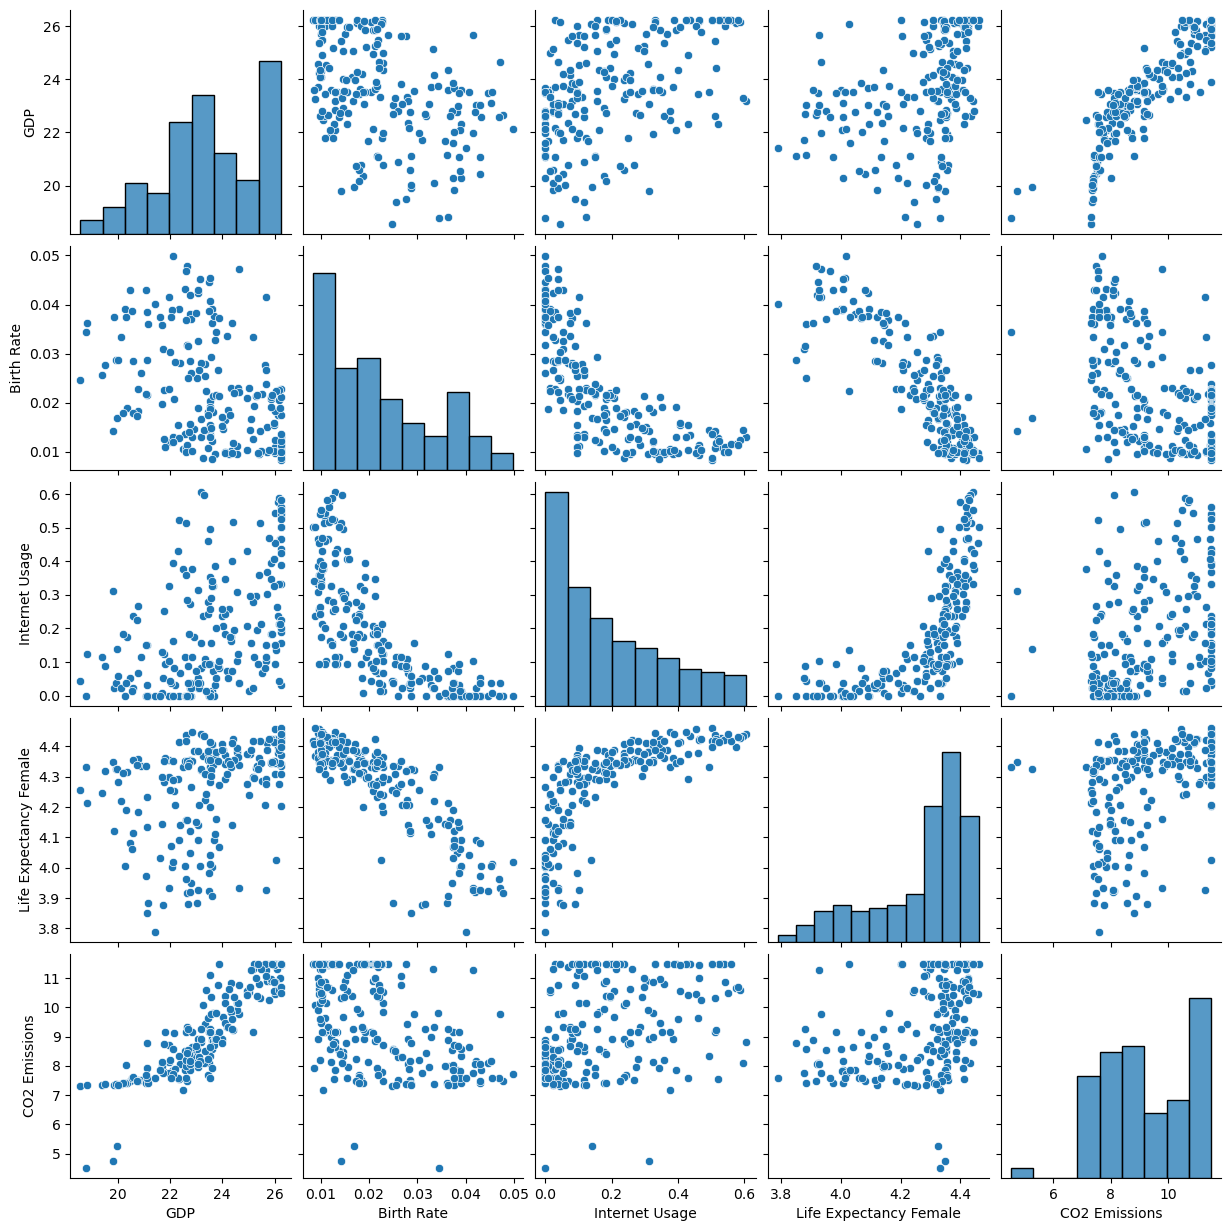

In [26]:
# Pairplot to visualize relationships between selected development indicators
sns.pairplot(df_country[['GDP','Birth Rate','Internet Usage','Life Expectancy Female','CO2 Emissions']])
plt.show()

In [27]:
#scaling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [28]:
std_sca=StandardScaler()

In [29]:
df_scaled=pd.DataFrame(std_sca.fit_transform(df_country),columns=df_country.columns,index=df_country.index)
df_scaled.head()

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Country,,,,,,,,,,,,,,,,,,,,
Afghanistan,1.828247,-0.755296,-1.668305,0.074794,-0.271351,1.139719,-0.911109,1.806739,-0.998552,0.340039,-1.131596,-1.061093,-0.837234,1.756002,-2.113535,-1.098212,0.894677,-1.400463,-0.247086,-0.283307
Albania,-0.698794,-0.550303,-0.294934,-1.599676,-0.343682,-0.074779,-0.081443,-0.500793,-0.099432,0.361807,0.733092,0.697749,0.060958,-0.403760,0.453222,0.356087,-0.143032,-0.256566,0.283818,0.450020
Algeria,-0.036384,1.332672,-0.134543,0.935129,0.998549,-1.187210,-0.253354,-0.136356,-0.739377,-0.959804,0.101449,0.252313,-0.154275,-0.060322,0.591475,-0.579527,1.046076,0.415795,-0.609610,-0.066406
American Samoa,-0.177433,-0.100118,0.016782,0.074794,-0.028292,-0.096864,-0.003812,-0.382662,-0.572736,-0.130081,0.389982,0.313389,-0.129873,0.011654,0.279869,-0.410330,-2.047200,1.249311,0.000208,-0.037562
Andorra,-1.069466,-1.400051,0.016782,0.074794,-0.565694,-0.025122,1.451577,-1.042545,1.083550,-0.130081,0.389982,0.313389,0.440861,0.011654,0.279869,-0.410330,-1.905902,1.320988,0.000208,-0.037562


In [30]:
df_scaled.shape

(204, 20)

In [31]:
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

PCA(Principal Componenet Analysis)-Feature extraction and dimensionality reduction

In [32]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [33]:
pca=PCA()
pca1=pca.fit_transform(df_scaled)
pca.explained_variance_ratio_

array([5.36960580e-01, 1.58799511e-01, 6.55735084e-02, 4.48946388e-02,
       3.58135780e-02, 3.05530825e-02, 2.63809477e-02, 2.38984022e-02,
       1.81013416e-02, 1.22879427e-02, 1.13550219e-02, 9.07206997e-03,
       7.56886751e-03, 6.24670123e-03, 4.13948325e-03, 3.36055458e-03,
       2.67133119e-03, 1.63707817e-03, 6.45950549e-04, 3.94088480e-05])

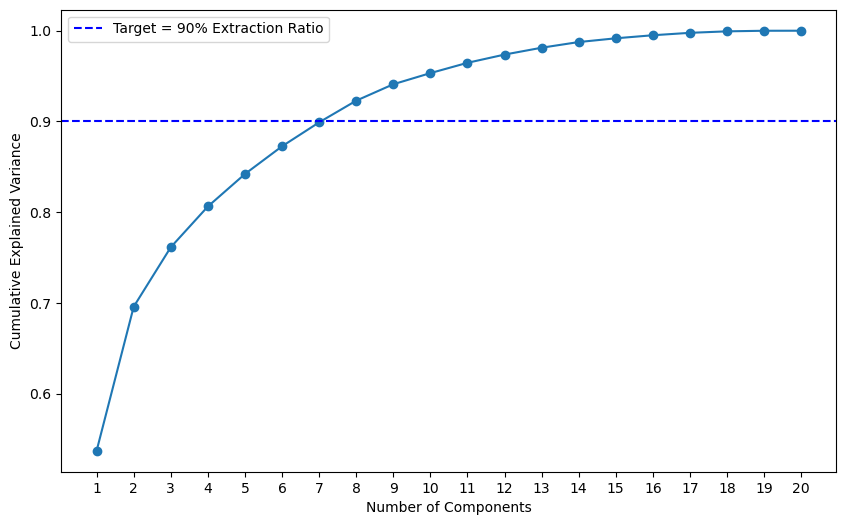

In [34]:
n = len(pca.explained_variance_ratio_)
x = range(1, n+1)  # [1, 2, 3, ..., n]
plt.figure(figsize=(10,6))
plt.plot(x, np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.9, color='blue', linestyle='--', label='Target = 90% Extraction Ratio')
plt.xticks(x)  
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.show()

90% Extraction ratio is given when we use 7 pca componets

In [35]:
pca=PCA(n_components=7)

In [36]:
#applying pca with 7 components over df_scaled
pca_result=pca.fit_transform(df_scaled)

In [37]:
pca.explained_variance_ratio_

array([0.53696058, 0.15879951, 0.06557351, 0.04489464, 0.03581358,
       0.03055308, 0.02638095])

In [38]:
pca_result

array([[ 3.89003414,  1.41012404,  2.44597657, ..., -0.08422444,
        -0.9743136 , -0.24650456],
       [-0.68730126, -1.22583613, -0.14106487, ..., -0.2929129 ,
        -0.83400123, -1.19790934],
       [-0.48504985,  1.59484294, -1.51757104, ..., -0.55096545,
        -0.39608321, -0.07123246],
       ...,
       [ 3.47856338,  1.37987603, -0.25612926, ...,  0.05277393,
        -0.67042678, -0.32889209],
       [ 5.23199744,  1.00155718,  1.4327803 , ...,  0.74580187,
        -0.53861293,  0.64059673],
       [ 3.85814932,  1.43739624,  0.47885604, ...,  0.90928508,
         1.21981931,  0.34088386]])

In [39]:
#used Elbow method to find optimum k-value
from sklearn.cluster import KMeans
inertia=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(pca_result)
    inertia.append(kmeans.inertia_)
print(inertia)

[3667.821452982117, 2040.3692563282723, 1598.829654572341, 1310.4532752636517, 1149.284508519435, 1151.2411529703004, 993.2348523002076, 936.4654175324223, 894.0366194457881, 869.1823726183754]


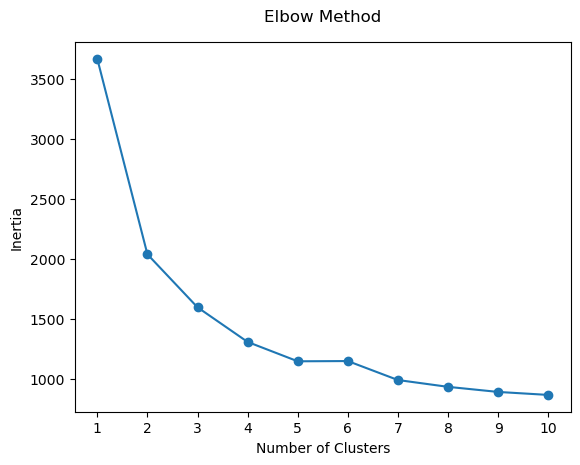

In [40]:
plt.plot(range(1,11),inertia,marker='o')
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method",pad=15)
plt.show()

Optimum number of clusters from Elbow method is 4,till 4 inertia drops largeley,after 4 its decrease is very much reduced

In [41]:
#kmeans clustering
kmeans=KMeans(n_clusters=4, random_state=42)

In [42]:
cluster=kmeans.fit(pca_result)
kmeans_labels=cluster.labels_

In [43]:
kmeans_score=silhouette_score(pca_result,kmeans_labels)
print(f'Silhouette score:{kmeans_score:.2f}')

Silhouette score:0.31


In [44]:
# Applying Hierarchical (Agglomerative) clustering and evaluating using Silhouette Score
hc = AgglomerativeClustering(n_clusters=4)
hc_labels = hc.fit_predict(df_scaled)

hc_score = silhouette_score(df_scaled, hc_labels)
print(f"Hierarchical silhouette score:{hc_score:2f}")

Hierarchical silhouette score:0.230344


The Silhouette Score for Hierarchical clustering is 0.25, which is slightly lower than K-Means, indicating weaker cluster separation.

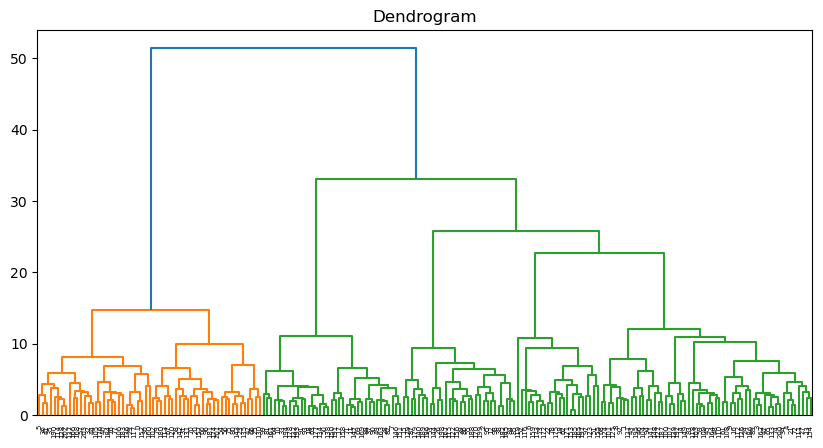

In [45]:
# Plotting dendrogram to visualize hierarchical clustering structure
linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

- The dendrogram shows how clusters are formed by merging data points. 
- Based on the larger vertical distances, around 4 clusters can be identified.

In [46]:
# Applying DBSCAN clustering and evaluating using silhouette score
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)


# Remove noise points (-1)
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(df_scaled[mask], dbscan_labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN could not form proper clusters")

DBSCAN could not form proper clusters


- DBSCAN could not form meaningful clusters for this dataset. 
- This is likely due to the high dimensional nature of the data and the lack of clear density-based separation between observations.

In [47]:
print("KMeans:", kmeans_score)
print("Hierarchical:", hc_score)

KMeans: 0.3077445484566752
Hierarchical: 0.23034368066154157


- Based on the Silhouette Scores, K-Means clustering performed better than Hierarchical clustering.
- K-Means achieved a higher score of 0.31 compared to 0.25 for Hierarchical clustering, indicating better-defined and more compact clusters.

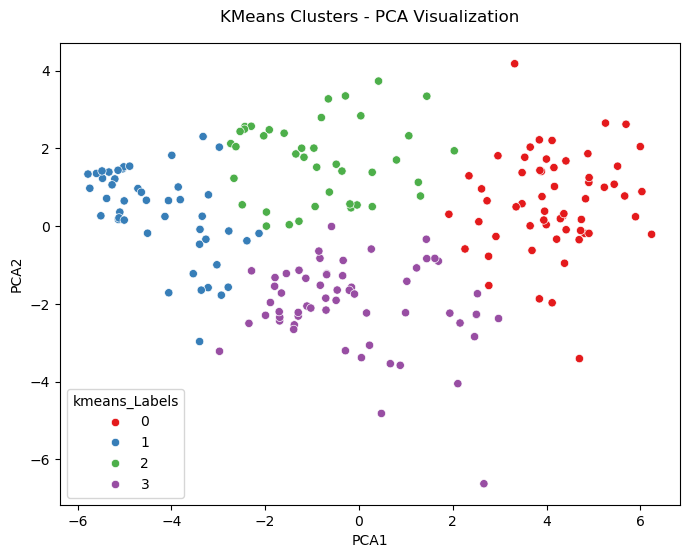

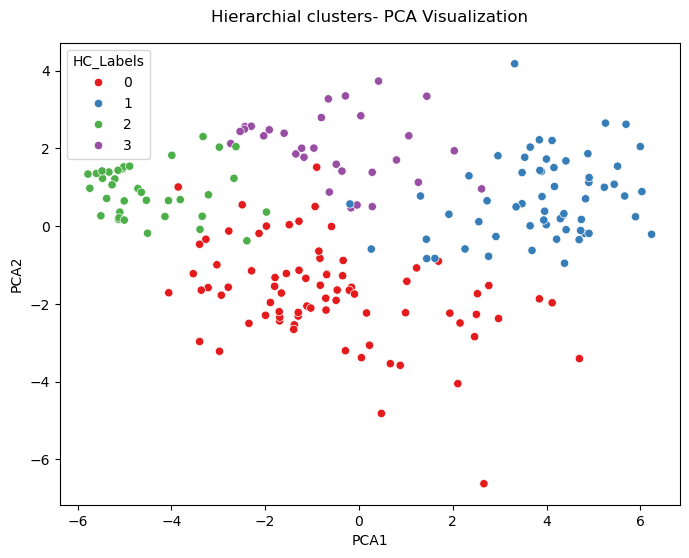

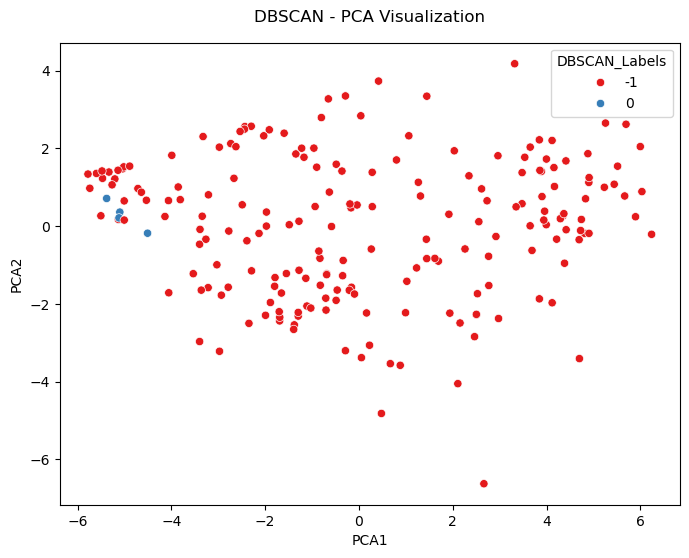

In [48]:
features=pd.DataFrame()
# Add to dataframe for plotting
features['PCA1'] = pca_result[:, 0]
features['PCA2'] = pca_result[:, 1]
features['kmeans_Labels']=kmeans_labels
features['HC_Labels']=hc_labels
features['DBSCAN_Labels']=dbscan_labels
#visulaizing kmeans clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x='PCA1', y='PCA2', hue='kmeans_Labels',palette='Set1')
plt.title('KMeans Clusters - PCA Visualization',pad=15)
plt.show()

#visulaizing Hierarchial clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x='PCA1', y='PCA2', hue='HC_Labels',palette='Set1')
plt.title('Hierarchial clusters- PCA Visualization',pad=15)
plt.show()

#visulaizing Dbscan clusters 
plt.figure(figsize=(8,6))
sns.scatterplot(data=features, x='PCA1', y='PCA2', hue='DBSCAN_Labels',palette='Set1')
plt.title('DBSCAN - PCA Visualization',pad=15)
plt.show()

- The above plots show the distribution of countries across different clusters formed using K-Means, Hierarchical, and DBSCAN algorithms after dimensionality reduction using PCA.
- K-Means and Hierarchical clustering show relatively clear cluster separation, while DBSCAN does not form well-defined clusters and classifies most points as noise.
- Based on visual observation, K-Means appears to form more distinct and compact clusters.

In [49]:
df_country['labels']=kmeans_labels
df_country.head(10)

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,...,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,labels
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0422,8.1546,2.7029,9.5790,23.0486,0.0836,4.0212,0.0795,0.0228,0.1322,...,4.0498,0.2564,0.3990,0.3979,0.0206,17.0502,0.2094,20.0187,19.5905,0
Albania,0.0146,8.4703,3.2158,8.0003,22.9088,0.0596,5.1349,0.0176,0.1759,0.1331,...,4.3041,0.4457,0.2298,0.5030,0.0843,14.8996,0.3911,20.8762,20.7303,3
Algeria,0.0218,11.3701,3.2757,10.3901,25.5027,0.0377,4.9041,0.0274,0.0669,0.0799,...,4.2397,0.4003,0.2567,0.5087,0.0433,17.3640,0.4978,19.4331,19.9277,2
American Samoa,0.0203,9.1636,3.3322,9.5790,23.5183,0.0592,5.2391,0.0208,0.0953,0.1133,...,4.2485,0.4055,0.2624,0.4959,0.0507,10.9533,0.6302,20.4181,19.9725,3
Andorra,0.0105,7.1616,3.3322,9.5790,22.4798,0.0606,7.1927,0.0031,0.3773,0.1133,...,4.2485,0.5257,0.2624,0.4959,0.0507,11.2462,0.6416,20.4181,19.9725,3
Angola,0.0472,9.7823,3.9408,9.2702,24.6452,0.0408,4.6591,0.1078,0.0377,0.1860,...,3.8792,0.2076,0.3904,0.4042,0.0242,16.6612,0.3147,19.4481,19.2639,0
Antigua and Barbuda,0.0182,7.5081,3.2219,9.2156,20.7662,0.0453,6.3580,0.0104,0.2683,0.1060,...,4.2926,0.7492,0.2443,0.5016,0.0694,11.3329,0.2518,19.6476,18.1503,3
Argentina,0.0175,11.4844,3.4352,10.8156,26.1390,0.0815,6.3778,0.0149,0.2384,0.1326,...,4.2799,0.5963,0.2316,0.4921,0.0982,17.4790,0.6431,22.1065,22.1221,1
Armenia,0.0137,8.5042,2.9281,8.1082,22.5766,0.0481,4.5795,0.0200,0.1161,0.1759,...,4.2616,0.3742,0.2000,0.5126,0.1034,14.9166,0.4949,19.4286,19.4915,3


In [50]:
# Print countries per cluster to confirm
for i in range(4):
    print(f"\n=== Cluster {i} ===")
    countries = df_country[df_country['labels'] == i].index.tolist()
    print(countries)


=== Cluster 0 ===
['Afghanistan', 'Angola', 'Benin', 'Bhutan', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kenya', 'Lao PDR', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Niger', 'Nigeria', 'Papua New Guinea', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Sudan', 'Sudan', 'Swaziland', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen, Rep.', 'Zambia', 'Zimbabwe']

=== Cluster 1 ===
['Argentina', 'Australia', 'Austria', 'Belgium', 'Bulgaria', 'Canada', 'Chile', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong SAR, China', 'Hungary', 'Ic

In [51]:
dict1={
    'Metric':['Infant Mortality','Birth Rate','Internet Usage','Gdp'],
    'Under_Developed':['Highest','Highest','Low','Lowest'],
    'Emerging':['High/Medium','Medium','Rising','Medium'],
    'Developing':['Low','Low','High','High'],
    'Highly_Developed':['Lowest','Lowest','Highest','Highest']
}
Metric_table=pd.DataFrame(dict1)
Metric_table

,Metric,Under_Developed,Emerging,Developing,Highly_Developed
0,Infant Mortality,Highest,High/Medium,Low,Lowest
1,Birth Rate,Highest,Medium,Low,Lowest
2,Internet Usage,Low,Rising,High,Highest
3,Gdp,Lowest,Medium,High,Highest


In [52]:
df_country.groupby('labels').mean().T

labels,0,1,2,3
Birth Rate,0.0366,0.0116,0.0202,0.0180
CO2 Emissions,8.2329,10.6017,10.9590,8.2486
Days to Start Business,3.5502,3.0127,3.4097,3.2982
Energy Usage,9.1641,10.0427,10.2234,8.9368
GDP,22.3885,25.4683,25.1708,22.1443
Health Exp % GDP,0.0562,0.0766,0.0483,0.0623
Health Exp/Capita,3.7711,6.8037,5.0907,5.5541
Infant Mortality Rate,0.0672,0.0067,0.0256,0.0186
Internet Usage,0.0295,0.4129,0.1383,0.2150
Lending Interest,0.1445,0.0849,0.1195,0.1192


- The above table shows the mean values of different features for each cluster formed using K-Means.
- Cluster 0 represents countries with higher birth rates, higher infant mortality, and lower internet usage, indicating Under developed countries.
- Cluster 1 represents countries with lowest infant mortality rates,lowest birth rates and highest GDP, indicating Highly Developed countries.
- Cluster 2 represents countries with medium infant mortality rates,medium birth rates and medium GDP,indiacting Developing countries
- Cluster 3 represents countries with lower infant mortality rates,lower birth rates and lowest GDP,indicating Emerging countries.
- Overall, the clustering groups countries based on their economic and social development levels.

In [53]:
df_country.columns

Index(['Birth Rate', 'CO2 Emissions', 'Days to Start Business', 'Energy Usage',
       'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound', 'labels'],
      dtype='object')

In [54]:
df_country[df_country['labels']==0]

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,...,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,labels
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0422,8.1546,2.7029,9.5790,23.0486,0.0836,4.0212,0.0795,0.0228,0.1322,...,4.0498,0.2564,0.3990,0.3979,0.0206,17.0502,0.2094,20.0187,19.5905,0
Angola,0.0472,9.7823,3.9408,9.2702,24.6452,0.0408,4.6591,0.1078,0.0377,0.1860,...,3.8792,0.2076,0.3904,0.4042,0.0242,16.6612,0.3147,19.4481,19.2639,0
Benin,0.0390,8.3419,3.4215,8.2241,22.3243,0.0439,3.2757,0.0705,0.0000,0.1133,...,4.0417,0.2505,0.3665,0.4245,0.0281,15.9512,0.3394,18.7566,18.7006,0
Bhutan,0.0228,7.4980,3.8015,9.2177,20.7610,0.0491,4.2809,0.0428,0.0669,0.1355,...,4.1791,0.3199,0.2901,0.4833,0.0411,13.3993,0.2725,17.4264,19.3064,0
Bolivia,0.0279,9.4152,3.8419,8.6757,23.3517,0.0538,4.3665,0.0420,0.1092,0.1406,...,4.1589,0.3254,0.3200,0.4561,0.0439,16.0673,0.4985,19.5236,19.5280,0
Botswana,0.0250,8.5828,3.9408,7.9915,23.0180,0.0506,5.6315,0.0442,0.0451,0.1377,...,3.8728,0.4938,0.3051,0.4767,0.0321,14.4520,0.4398,19.4761,19.0384,0
Burkina Faso,0.0432,7.8544,3.2522,9.5790,22.5743,0.0630,3.3726,0.0788,0.0000,0.1133,...,3.9761,0.1563,0.3808,0.4127,0.0254,16.4478,0.2024,18.8988,18.7145,0
Burundi,0.0429,7.4093,2.8241,9.5790,21.0611,0.0809,2.6554,0.0705,0.0000,0.1507,...,3.9182,0.0597,0.3758,0.4168,0.0264,15.9106,0.0922,14.4492,17.8367,0
Cambodia,0.0260,8.2907,3.9408,8.4689,22.7931,0.0588,3.5487,0.0510,0.0000,0.1133,...,4.1850,0.2683,0.3027,0.4708,0.0442,16.4214,0.1766,20.7396,18.9229,0


In [55]:
cluster_names = {
    0: "Under Developed",
    1: "Highly Developed",
    2: "Developing",
    3: "Emerging"
}

df_country['Development_Level'] = df_country['labels'].map(cluster_names)

df_country[['labels','Development_Level']].head()

,labels,Development_Level
Country,,
Afghanistan,0,Under Developed
Albania,3,Emerging
Algeria,2,Developing
American Samoa,3,Emerging
Andorra,3,Emerging


In [56]:
file1="scaling_file.pkl"
file2="pca_file.pkl"
file3="kmeans_file.pkl"

In [59]:
pickle.dump(std_sca,open(file1,'wb'))
pickle.dump(pca,open(file2,'wb'))
pickle.dump(kmeans,open(file3,'wb'))

In [57]:
df_country

,Birth Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,...,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,labels,Development_Level
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0422,8.1546,2.7029,9.5790,23.0486,0.0836,4.0212,0.0795,0.0228,0.1322,...,0.2564,0.3990,0.3979,0.0206,17.0502,0.2094,20.0187,19.5905,0,Under Developed
Albania,0.0146,8.4703,3.2158,8.0003,22.9088,0.0596,5.1349,0.0176,0.1759,0.1331,...,0.4457,0.2298,0.5030,0.0843,14.8996,0.3911,20.8762,20.7303,3,Emerging
Algeria,0.0218,11.3701,3.2757,10.3901,25.5027,0.0377,4.9041,0.0274,0.0669,0.0799,...,0.4003,0.2567,0.5087,0.0433,17.3640,0.4978,19.4331,19.9277,2,Developing
American Samoa,0.0203,9.1636,3.3322,9.5790,23.5183,0.0592,5.2391,0.0208,0.0953,0.1133,...,0.4055,0.2624,0.4959,0.0507,10.9533,0.6302,20.4181,19.9725,3,Emerging
Andorra,0.0105,7.1616,3.3322,9.5790,22.4798,0.0606,7.1927,0.0031,0.3773,0.1133,...,0.5257,0.2624,0.4959,0.0507,11.2462,0.6416,20.4181,19.9725,3,Emerging
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,0.0166,11.2771,3.6975,10.5933,25.0789,0.0590,3.9645,0.0229,0.1563,0.1100,...,0.4358,0.2360,0.5119,0.0633,17.7606,0.2464,21.8007,20.7206,2,Developing
Virgin Islands (U.S.),0.0129,9.1636,3.3322,9.5790,23.5183,0.0592,5.2391,0.0208,0.2564,0.1133,...,0.4003,0.2028,0.5074,0.1082,11.5837,0.6618,20.8877,19.9725,3,Emerging
"Yemen, Rep.",0.0343,9.7878,3.5888,8.8720,23.7511,0.0472,3.9120,0.0533,0.0524,0.1774,...,0.1951,0.3702,0.4218,0.0269,16.8439,0.2586,19.9496,19.2285,0,Under Developed


In [58]:
df_country.to_csv("country_clusters.csv")